# SegmentForge: CRISP-DM Customer Intelligence Clustering

This notebook reads frozen, reproducible outputs from the executed pipeline. Raw customer transactions are not embedded.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
TABLES = ROOT / 'artifacts' / 'tables'
FIGURES = ROOT / 'artifacts' / 'figures'
MODELS = ROOT / 'artifacts' / 'models'
print('Project root resolved from the current notebook context')

Project root resolved from the current notebook context


## Business and data understanding

The objective is descriptive customer segmentation for analysis and controlled hypotheses. It is not causal targeting or customer-lifetime-value prediction.

,check,value
0,rows,541909
1,columns,8
2,exact_duplicate_rows,5268
3,missing_customer_id,135080
4,missing_description,1454
5,cancellation_invoice_rows,9288
6,nonpositive_quantity_rows,10624
7,nonpositive_price_rows,2517
8,unique_identified_customers,4372
9,minimum_invoice_date,2010-12-01T08:26:00


,reason,rows,share_of_raw
0,exact duplicate,5268,0.009721
1,missing CustomerID,135080,0.249267
2,cancellation invoice,9288,0.017139
3,nonpositive quantity,10624,0.019605
4,nonpositive price,2517,0.004645


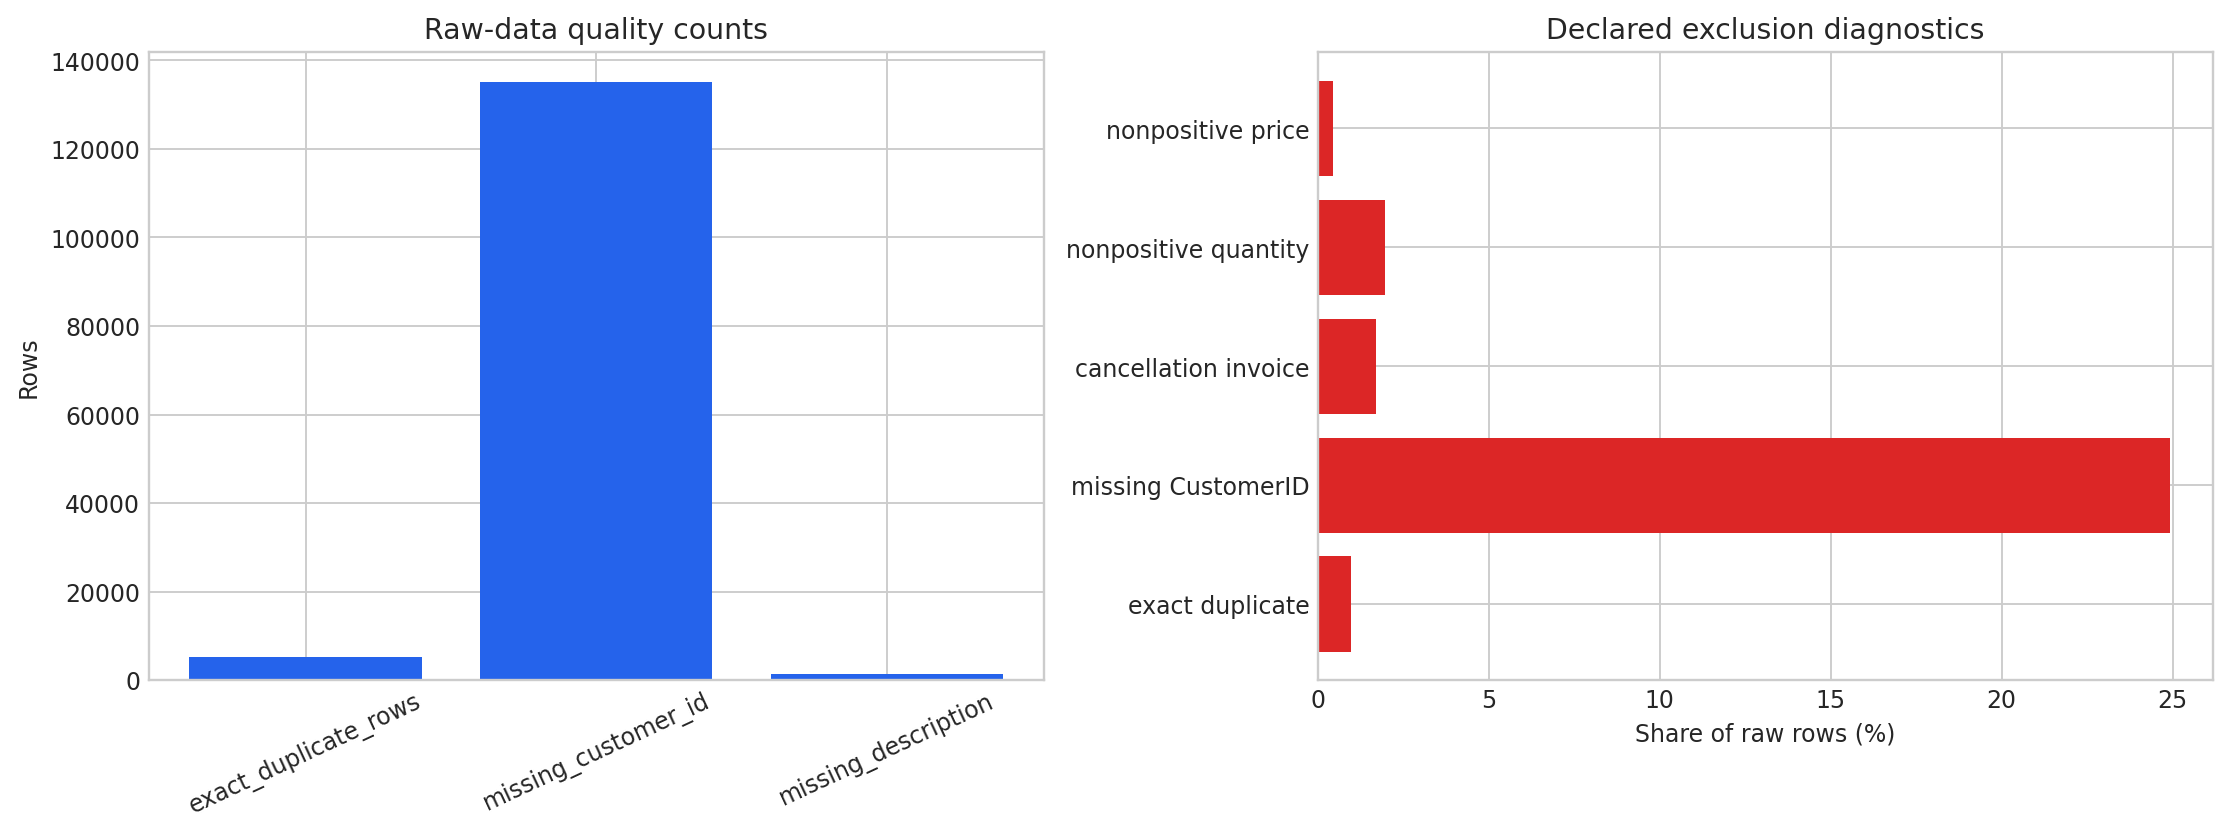

In [2]:
quality = pd.read_csv(TABLES / 'raw_quality_summary.csv')
exclusions = pd.read_csv(TABLES / 'exclusion_audit.csv')
display(quality, exclusions)
display(Image(filename=str(FIGURES / 'data_quality_overview.png')))

## Data preparation

Recency, Frequency, and Monetary features use valid positive purchases and a fixed snapshot date. Cancellations are retained as a separate diagnostic feature. Identifiers are excluded from clustering.

,Unnamed: 0,count,unique,top,freq,mean,min,25%,50%,75%,max,std
0,frequency,4338.0,NaN,NaN,NaN,4.272014753342554,1.0,1.0,2.0,5.0,209.0,7.697998
1,monetary,4338.0,NaN,NaN,NaN,2048.688080682342,3.75,306.48249999999996,668.57,1660.5974999999999,280206.02,8985.230220
8,recency_days,4338.0,NaN,NaN,NaN,93.05947441217151,1.0,18.0,51.0,142.75,374.0,100.012264


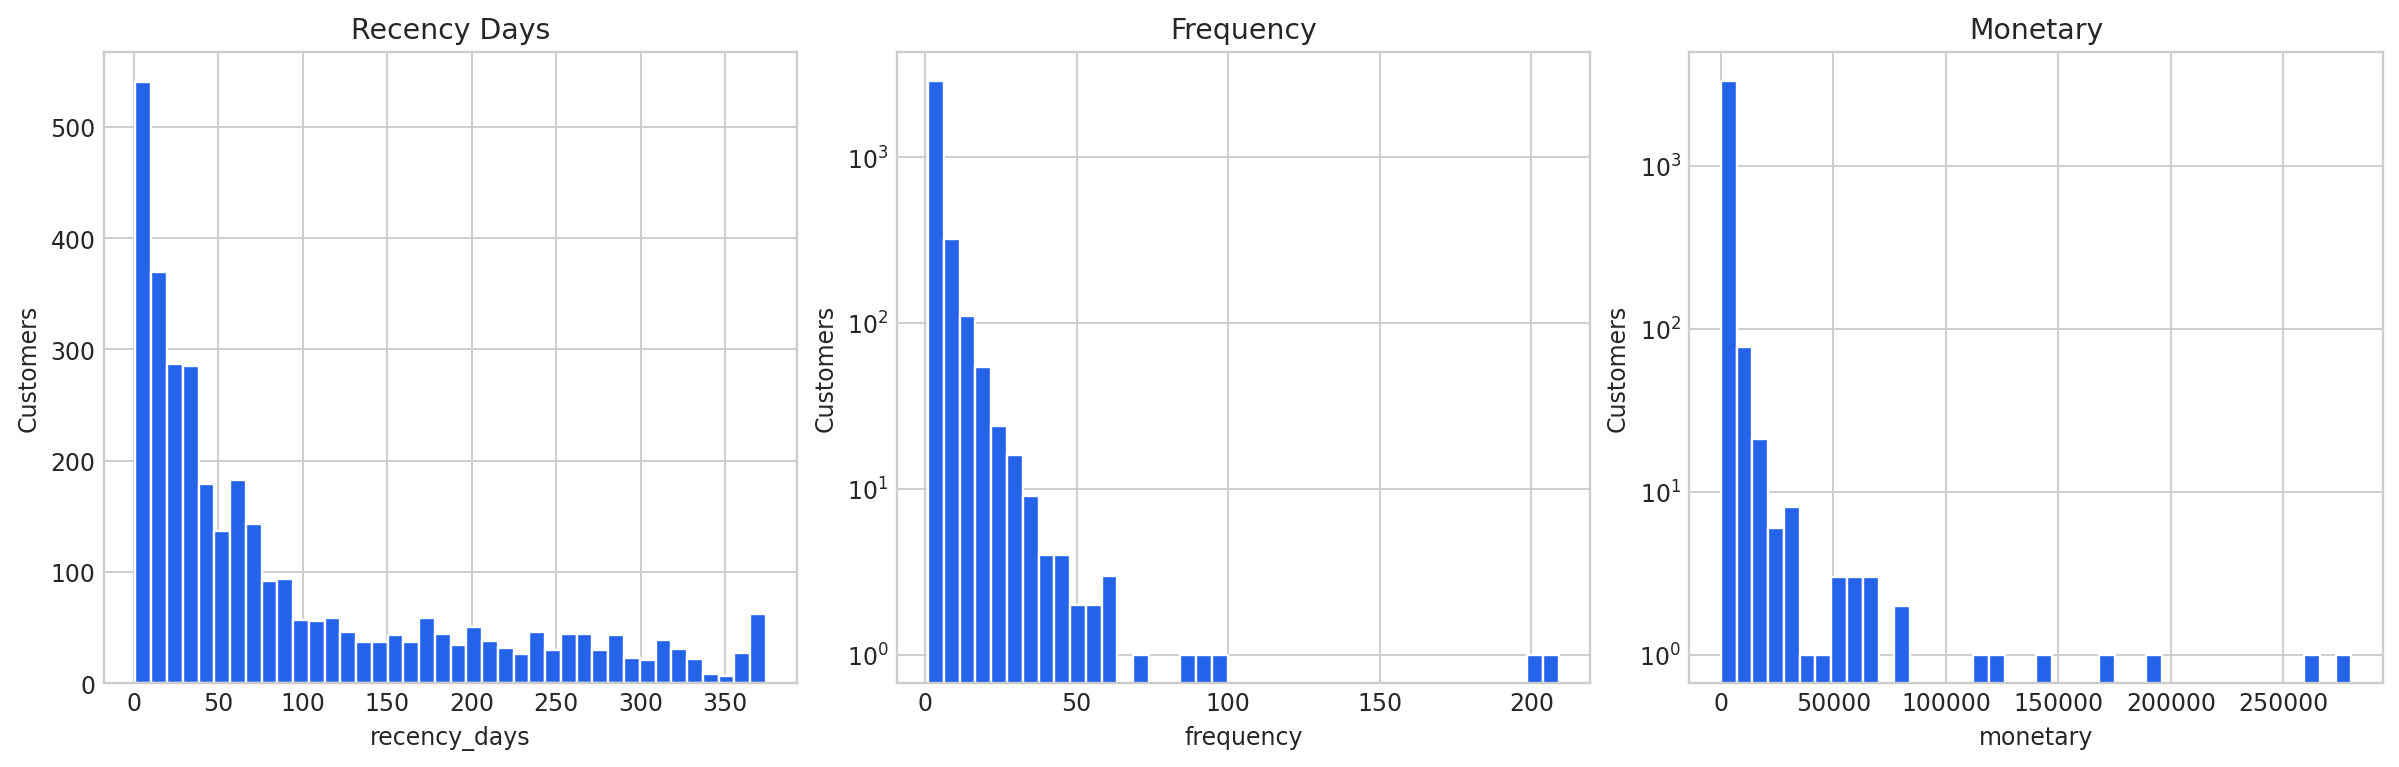

In [3]:
summary = pd.read_csv(TABLES / 'customer_feature_summary.csv')
display(summary.loc[summary['Unnamed: 0'].isin(['recency_days','frequency','monetary'])])
display(Image(filename=str(FIGURES / 'rfm_distributions.png')))

## Modeling and bounded AutoResearch

The search changes one configuration component at a time and evaluates cohesion, separation, stability, balance, interpretability, and complexity. Rejected trials remain auditable.

,trial_id,algorithm,n_clusters,feature_view,transformation,scaler,outlier_policy,silhouette,stability_ari_mean,objective
0,13,kmeans,4,rfm,yeo_johnson,standard,keep,0.333146,0.988823,0.812837
1,20,kmeans,4,rfm,yeo_johnson,standard,winsorize,0.334819,0.980686,0.811405
2,35,kmeans,2,behavioral,yeo_johnson,standard,keep,0.327345,0.964040,0.800525
3,12,kmeans,3,rfm,yeo_johnson,robust,keep,0.319573,0.948134,0.800337
4,41,kmeans,2,behavioral,yeo_johnson,robust,winsorize,0.305687,0.981214,0.800183
5,34,gaussian_mixture,2,behavioral,yeo_johnson,standard,keep,0.325408,0.959420,0.797888
6,7,kmeans,4,rfm,yeo_johnson,robust,keep,0.330425,0.927156,0.796302
7,18,kmeans,3,rfm,yeo_johnson,standard,keep,0.327217,0.904358,0.791312
8,21,kmeans,5,rfm,yeo_johnson,standard,keep,0.320949,0.941629,0.788910
9,6,kmeans,3,rfm,log1p,robust,keep,0.339063,0.925839,0.786567


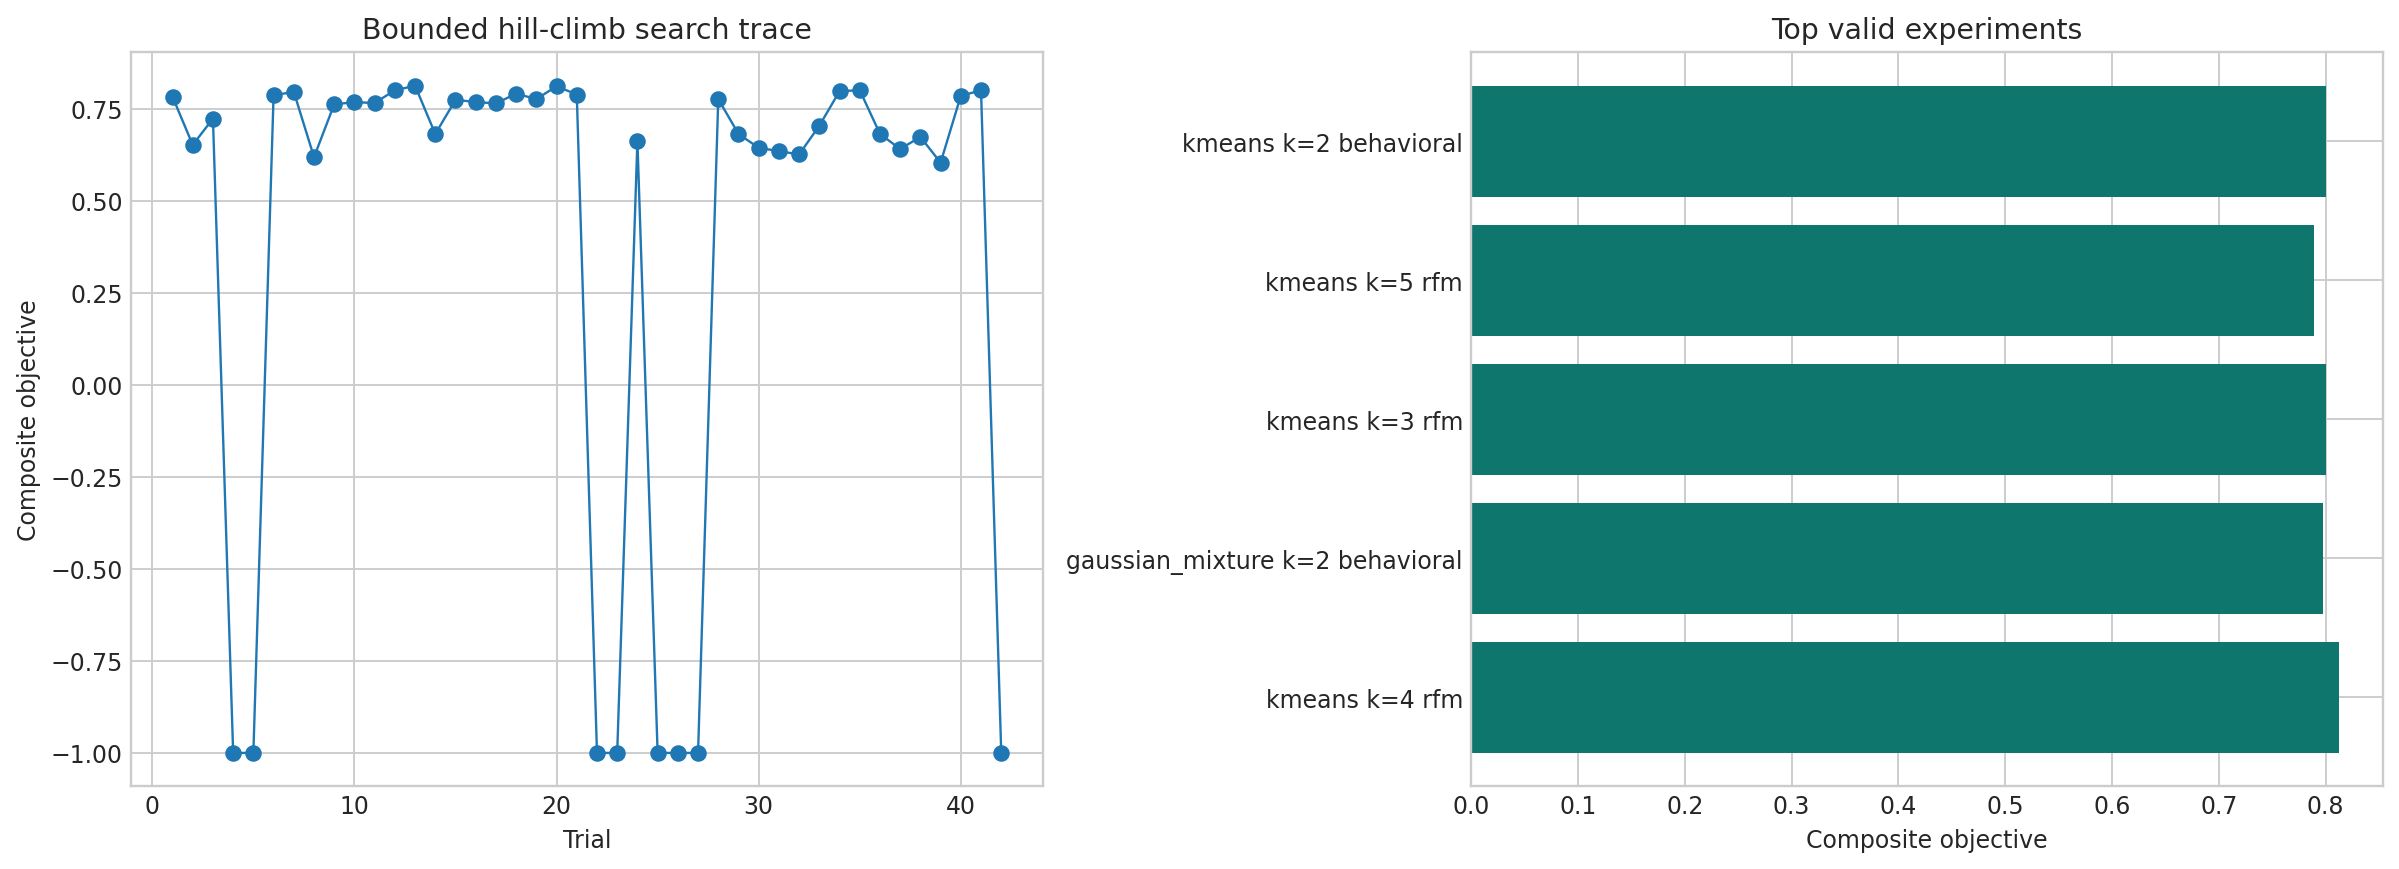

In [4]:
leaderboard = pd.read_csv(TABLES / 'autoresearch_leaderboard.csv')
cols = ['trial_id','algorithm','n_clusters','feature_view','transformation','scaler','outlier_policy','silhouette','stability_ari_mean','objective']
display(leaderboard[cols].head(10))
display(Image(filename=str(FIGURES / 'autoresearch_search.png')))

## Locked evaluation and interpretation

The audit population was not used during hill climbing. Internal clustering metrics are not classification accuracy.

,partition,silhouette,calinski_harabasz,davies_bouldin,minimum_cluster_share,maximum_cluster_share,stability_ari_mean,stability_ari_sd
0,discovery,0.333146,2872.256930,1.018365,0.214929,0.293349,0.988823,0.002512
1,locked_audit,0.338317,741.298188,1.021934,0.231285,0.275978,NaN,NaN


,cluster,persona,customers,customer_share,revenue_share,evidence
0,0,High-value frequent customers,1064,0.245274,0.722737,Median R/F/M = 10 days / 7 invoices / £2708.86.
1,1,Established mid-value customers,1257,0.289765,0.198851,Median R/F/M = 66 days / 3 invoices / £993.54.
2,2,Recent occasional customers,947,0.218303,0.040471,Median R/F/M = 32 days / 1 invoices / £322.80.
3,3,Long-recency customers,1070,0.246657,0.037941,Median R/F/M = 237 days / 1 invoices / £252.77.


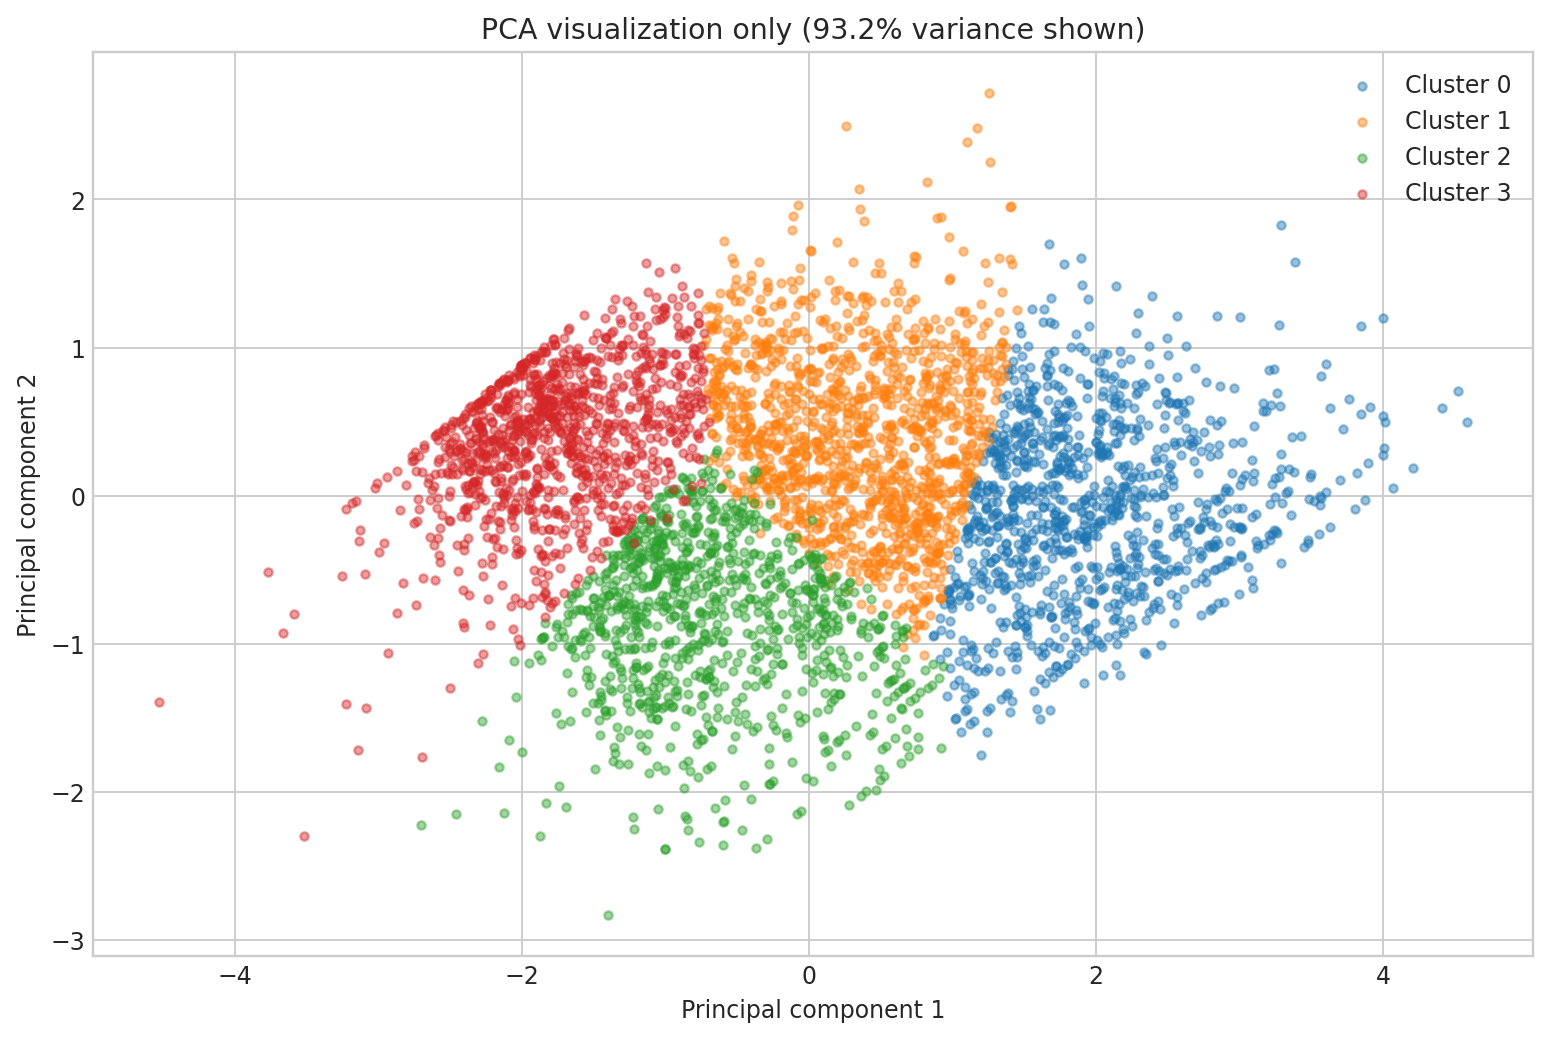

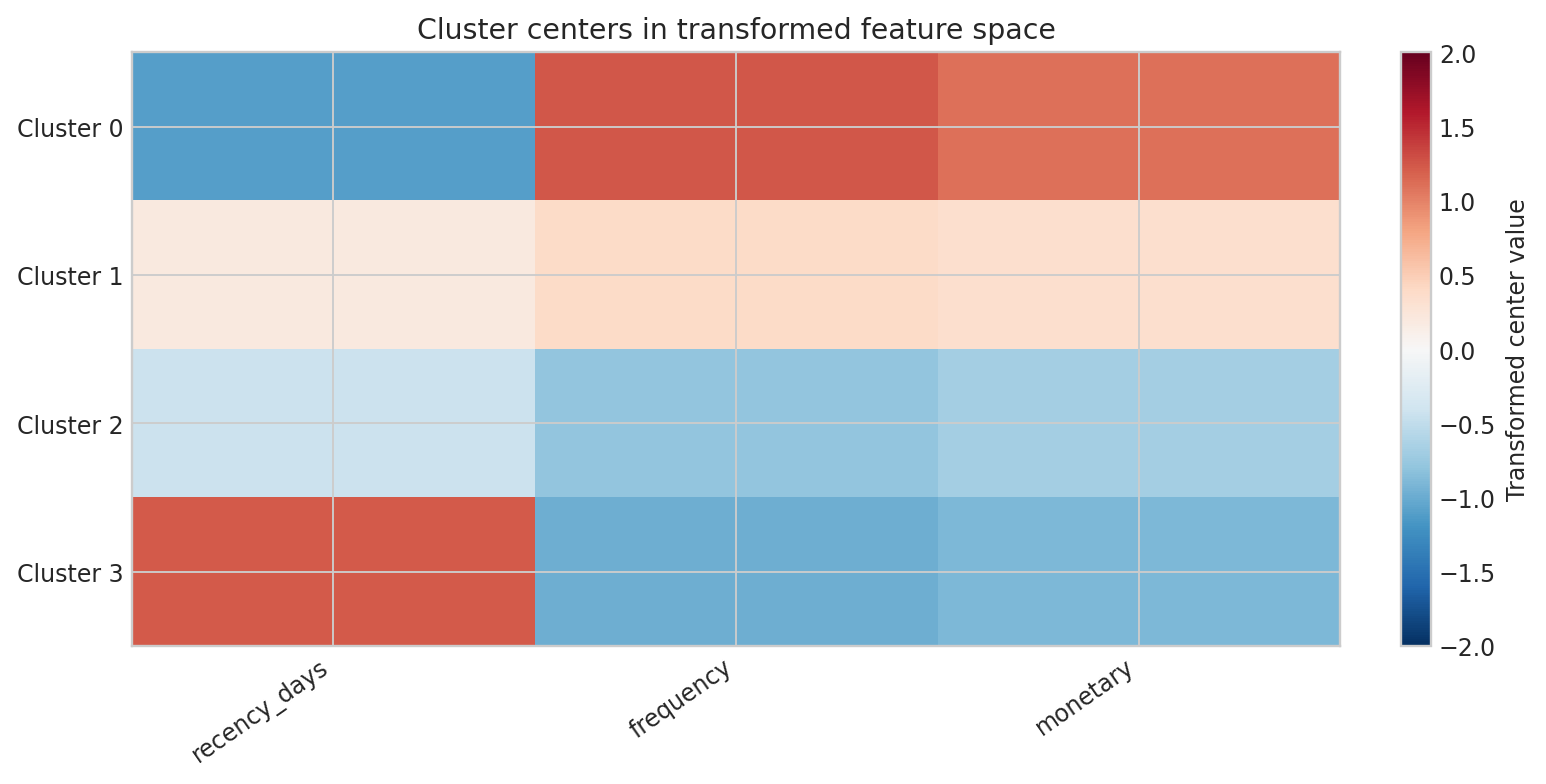

In [5]:
metrics = pd.read_csv(TABLES / 'locked_solution_metrics.csv')
profiles = pd.read_csv(TABLES / 'cluster_profiles.csv')
display(metrics, profiles[['cluster','persona','customers','customer_share','revenue_share','evidence']])
display(Image(filename=str(FIGURES / 'cluster_pca_projection.png')))
display(Image(filename=str(FIGURES / 'cluster_profile_heatmap.png')))

## Deployment and limitations

The Streamlit dashboard exposes frozen aggregate artifacts, experiment history, masked customer lookup, quality evidence, and model metadata. The data represent one retailer in 2010–2011; segments can drift and do not prove intent or campaign impact.

In [6]:
metadata = json.loads((MODELS / 'segmentforge_metadata.json').read_text())
metadata